<a href="https://colab.research.google.com/github/beyzaturku/2209/blob/main/yolo_models/yolo9_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
!pip install ultralytics

In [79]:
!pip install -U ultralytics

In [56]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [83]:
from ultralytics import YOLO

def train_yolo():
    model = YOLO("yolov9s.pt")  # Yüklenmiş olmalı (veya yol belirtilmeli)

    results = model.train(
        data='/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml',
        epochs=50,
        imgsz=640,
        batch=16,
        project="/content/drive/MyDrive/altitude/high_alt_object_detection/yolo9_train",
        name="yolov9_new_train",
        save=True,
        save_period=5
    )
    return model, results

print("1. Model eğitimi başlatılıyor...")
model, results = train_yolo()

1. Model eğitimi başlatılıyor...


100%|██████████| 14.7M/14.7M [00:00<00:00, 128MB/s] 


Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov9_new_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

train: Scanning /content/drive/MyDrive/altitude/high_alt_object_detection/dataset/labels/train.cache... 281 images, 0 backgrounds, 0 corrupt: 100%|██████████| 281/281 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

      50/50      4.53G        0.9     0.4539     0.7915        115        640: 100%|██████████| 18/18 [00:04<00:00,  4.41it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  5.42it/s]

                   all         71        925      0.972      0.967      0.984      0.824



50 epochs completed in 0.081 hours.
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo9_train/yolov9_new_train/weights/last.pt, 15.2MB
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo9_train/yolov9_new_train/weights/best.pt, 15.2MB

Validating /content/drive/MyDrive/altitude/high_alt_object_detection/yolo9_train/yolov9_new_train/weights/best.pt...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv9s summary (fused): 197 layers, 7,168,636 parameters, 0 gradients, 26.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.56it/s]


                   all         71        925      0.973      0.967      0.984      0.824
                   car         71        912      0.946      0.955      0.973      0.709
                   bus         13         13          1      0.979      0.995      0.939
Speed: 0.1ms preprocess, 1.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/drive/MyDrive/altitude/high_alt_object_detection/yolo9_train/yolov9_new_train


In [84]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import cv2

def create_metrics_table(csv_path):
    # CSV dosyasını oku
    df = pd.read_csv(csv_path)

    # Önemli sütunları seç ve yeniden adlandır
    metrics_df = df[['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                     'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                     'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss']].copy()

    # Sütun isimlerini sadeleştir
    metrics_df.columns = ['Epoch', 'Train_Box_Loss', 'Train_Cls_Loss', 'Train_DFL_Loss',
                         'Precision', 'Recall', 'mAP50', 'mAP50_95',
                         'Val_Box_Loss', 'Val_Cls_Loss', 'Val_DFL_Loss']

    print("Model Performans Metrikleri:")
    print(metrics_df.tail(10))  # Son 10 epoch
    return metrics_df

def visualize_results(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Loss grafikleri (Train vs Val)
    axes[0,0].plot(df['Epoch'], df['Train_Box_Loss'], label='Train Box Loss', color='blue')
    axes[0,0].plot(df['Epoch'], df['Val_Box_Loss'], label='Val Box Loss', color='red')
    axes[0,0].set_title('Box Loss Eğrileri')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)

    # mAP grafikleri
    axes[0,1].plot(df['Epoch'], df['mAP50'], label='mAP50', color='green')
    axes[0,1].plot(df['Epoch'], df['mAP50_95'], label='mAP50-95', color='orange')
    axes[0,1].set_title('mAP Metrikleri')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('mAP')
    axes[0,1].legend()
    axes[0,1].grid(True)

    # Precision ve Recall
    axes[1,0].plot(df['Epoch'], df['Precision'], label='Precision', color='purple')
    axes[1,0].plot(df['Epoch'], df['Recall'], label='Recall', color='brown')
    axes[1,0].set_title('Precision & Recall')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Değer')
    axes[1,0].legend()
    axes[1,0].grid(True)

    # Tüm Loss türleri
    axes[1,1].plot(df['Epoch'], df['Train_Box_Loss'], label='Box Loss')
    axes[1,1].plot(df['Epoch'], df['Train_Cls_Loss'], label='Cls Loss')
    axes[1,1].plot(df['Epoch'], df['Train_DFL_Loss'], label='DFL Loss')
    axes[1,1].set_title('Eğitim Loss Türleri')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Loss')
    axes[1,1].legend()
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()

    # Son epoch özet tablosu
    final_metrics = df.iloc[-1]
    print(f"\nFinal Epoch ({int(final_metrics['Epoch'])}) Sonuçları:")
    print(f"mAP50: {final_metrics['mAP50']:.4f}")
    print(f"mAP50-95: {final_metrics['mAP50_95']:.4f}")
    print(f"Precision: {final_metrics['Precision']:.4f}")
    print(f"Recall: {final_metrics['Recall']:.4f}")

def test_single_image(model_path, image_path, conf_threshold=0.25, iou_threshold=0.45):
    model = YOLO(model_path)

    # Düşük threshold ile tahmin (daha fazla tespit için)
    results = model(image_path, conf=conf_threshold, iou=iou_threshold)

    # Görselleştirme
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Sonuçları çiz
    annotated_img = results[0].plot()

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img)
    plt.title(f'YOLO Tespiti (conf≥{conf_threshold}, iou≥{iou_threshold}) - {len(results[0].boxes) if results[0].boxes is not None else 0} nesne bulundu')
    plt.axis('off')
    plt.show()

    # Detay bilgiler
    if results[0].boxes is not None:
        print(f"\nToplam {len(results[0].boxes)} nesne tespit edildi:")
        print("-" * 40)
        for i, box in enumerate(results[0].boxes):
            conf = box.conf.item()
            cls = int(box.cls.item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            print(f"Nesne {i+1}: Sınıf {cls}, Güven: {conf:.3f}, Box: [{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]")
    else:
        print("Hiç nesne tespit edilmedi!")

    return results

def compare_thresholds(model_path, image_path):
    """Farklı confidence ve IOU threshold'larını karşılaştır"""
    thresholds = [
        (0.5, 0.5),   # Varsayılan (yüksek)
        (0.3, 0.4),   # Orta
        (0.1, 0.3)    # Düşük (daha hassas)
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (conf, iou) in enumerate(thresholds):
        model = YOLO(model_path)
        results = model(image_path, conf=conf, iou=iou)

        annotated_img = results[0].plot()

        axes[i].imshow(annotated_img)
        axes[i].set_title(f'conf={conf}, iou={iou}\n{len(results[0].boxes) if results[0].boxes is not None else 0} tespit')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


2. CSV'den metrikler okunuyor...
Model Performans Metrikleri:
    Epoch  Train_Box_Loss  Train_Cls_Loss  Train_DFL_Loss  Precision   Recall  \
40     41         1.08819         0.52795         0.79825    0.97889  0.96649   
41     42         0.98798         0.50067         0.80038    0.97020  0.95720   
42     43         1.00425         0.49472         0.79816    0.96971  0.96311   
43     44         0.98672         0.48733         0.79430    0.97608  0.96650   
44     45         0.96436         0.47559         0.80086    0.97406  0.96449   
45     46         0.95261         0.47120         0.80150    0.97569  0.96932   
46     47         0.97008         0.47502         0.80197    0.97321  0.96126   
47     48         0.92282         0.45616         0.79458    0.95912  0.96384   
48     49         0.92832         0.45958         0.79315    0.96936  0.95819   
49     50         0.90000         0.45391         0.79147    0.97185  0.96699   

      mAP50  mAP50_95  Val_Box_Loss  Val_Cls_

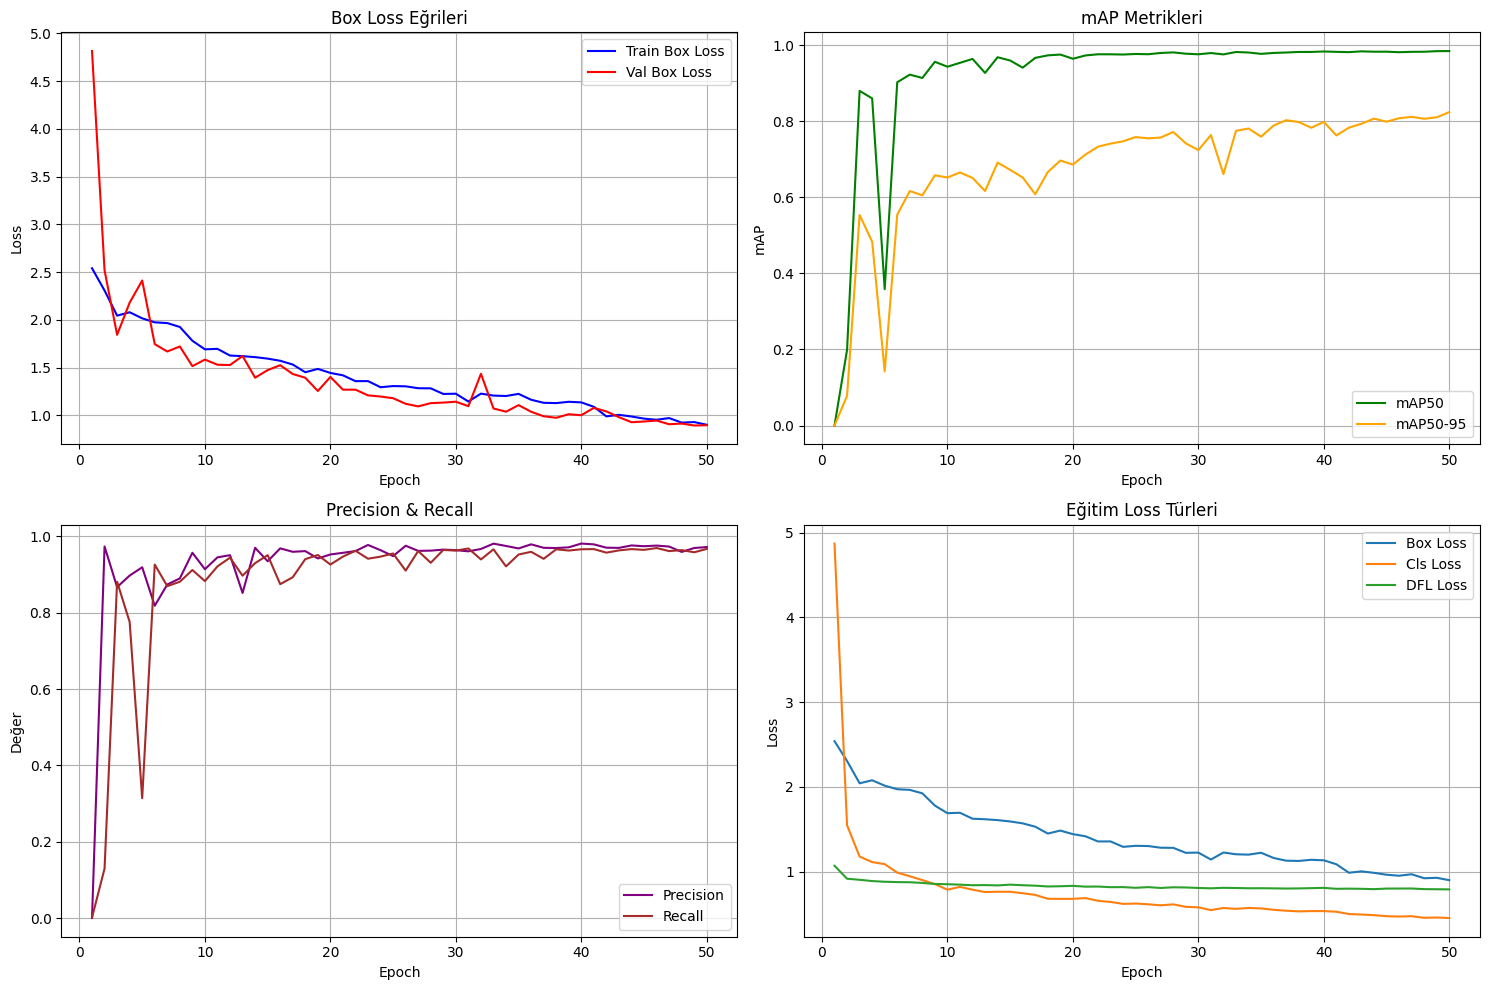


Final Epoch (50) Sonuçları:
mAP50: 0.9841
mAP50-95: 0.8237
Precision: 0.9718
Recall: 0.9670

4. Tek görsel test ediliyor...

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 8 cars, 58.5ms
Speed: 2.4ms preprocess, 58.5ms inference, 2.1ms postprocess per image at shape (1, 3, 352, 640)


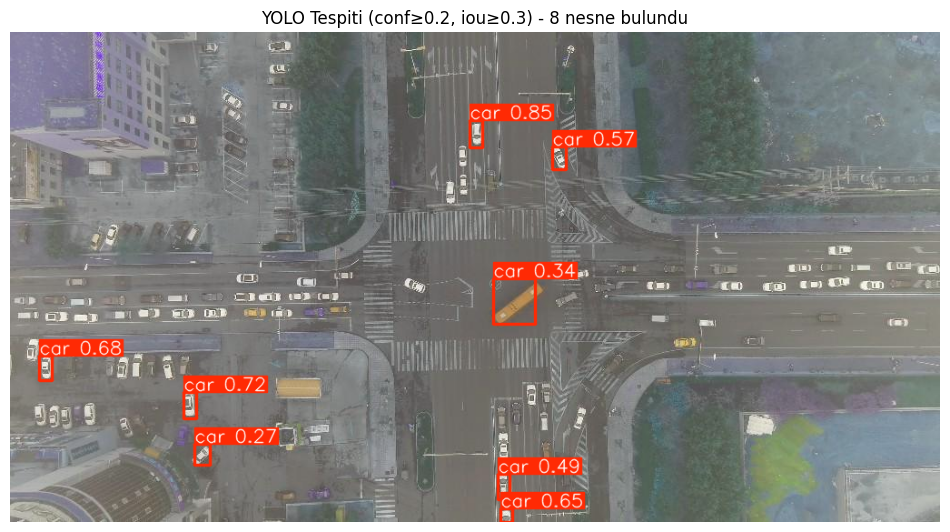


Toplam 8 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.854, Box: [507,98,521,128]
Nesne 2: Sınıf 0, Güven: 0.720, Box: [192,398,206,426]
Nesne 3: Sınıf 0, Güven: 0.678, Box: [32,358,47,384]
Nesne 4: Sınıf 0, Güven: 0.654, Box: [540,525,553,540]
Nesne 5: Sınıf 0, Güven: 0.567, Box: [597,127,612,152]
Nesne 6: Sınıf 0, Güven: 0.489, Box: [538,487,551,515]
Nesne 7: Sınıf 0, Güven: 0.343, Box: [533,273,579,323]
Nesne 8: Sınıf 0, Güven: 0.272, Box: [204,454,220,478]

4. Farklı threshold'lar karşılaştırılıyor...

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 5 cars, 20.8ms
Speed: 2.0ms preprocess, 20.8ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 7 cars, 22.3ms
Speed: 2.2ms preprocess, 22.3ms inference, 2.6ms postprocess per

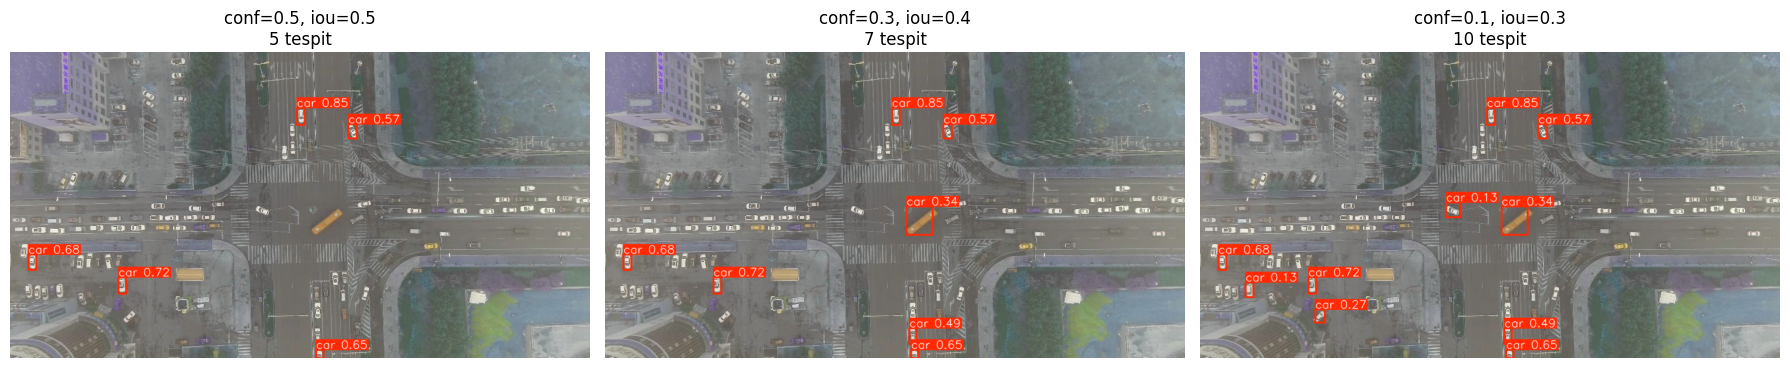

In [86]:
print("\n2. CSV'den metrikler okunuyor...")
df = create_metrics_table('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo9_train/yolov9_new_train/results.csv')

    # Görselleştir
print("\n3. Sonuçlar görselleştiriliyor...")
visualize_results(df)

    # Test et
print("\n4. Tek görsel test ediliyor...")
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo9_train/yolov9_new_train/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.2, iou_threshold=0.3)

print("\n4. Farklı threshold'lar karşılaştırılıyor...")
compare_thresholds('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo9_train/yolov9_new_train/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg')


image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 10 cars, 21.0ms
Speed: 2.0ms preprocess, 21.0ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)


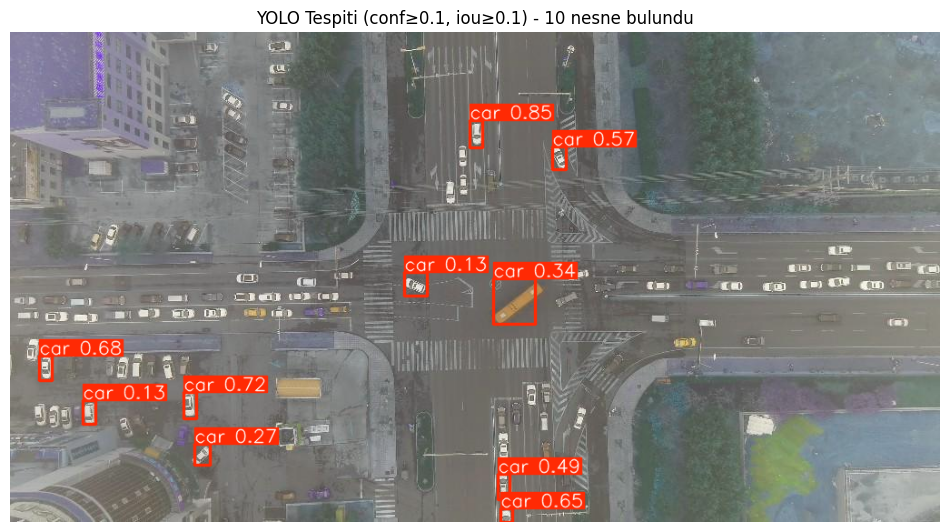


Toplam 10 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.854, Box: [507,98,521,128]
Nesne 2: Sınıf 0, Güven: 0.720, Box: [192,398,206,426]
Nesne 3: Sınıf 0, Güven: 0.678, Box: [32,358,47,384]
Nesne 4: Sınıf 0, Güven: 0.654, Box: [540,525,553,540]
Nesne 5: Sınıf 0, Güven: 0.567, Box: [597,127,612,152]
Nesne 6: Sınıf 0, Güven: 0.489, Box: [538,487,551,515]
Nesne 7: Sınıf 0, Güven: 0.343, Box: [533,273,579,323]
Nesne 8: Sınıf 0, Güven: 0.272, Box: [204,454,220,478]
Nesne 9: Sınıf 0, Güven: 0.132, Box: [435,265,460,292]
Nesne 10: Sınıf 0, Güven: 0.129, Box: [81,406,94,432]


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'vehicle', 2: 'truck', 3: 'bus'}
 obb: None
 orig_img: array([[[130, 124, 155],
         [130, 124, 155],
         [131, 125, 156],
         ...,
         [130, 146, 158],
         [136, 152, 164],
         [142, 158, 170]],
 
        [[133, 127, 158],
         [133, 127, 158],
         [133, 127, 158],
         ...,
         [132, 148, 160],
         [136, 152, 164],
         [139, 155, 167]],
 
        [[136, 130, 161],
         [136, 130, 161],
         [135, 129, 160],
         ...,
         [134, 150, 162],
         [135, 151, 163],
         [136, 152, 164]],
 
        ...,
 
        [[139, 136, 131],
         [137, 134, 129],
         [134, 131, 126],
         ...,
         [134, 139, 130],
         [133, 138, 129],
         [133, 138, 129]],
 
        [[139, 136, 132],
         [136, 133, 129],
         [132, 129, 125],

In [87]:
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo9_train/yolov9_new_train/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.1, iou_threshold=0.1)


image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 35 cars, 21.4ms
Speed: 2.1ms preprocess, 21.4ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)


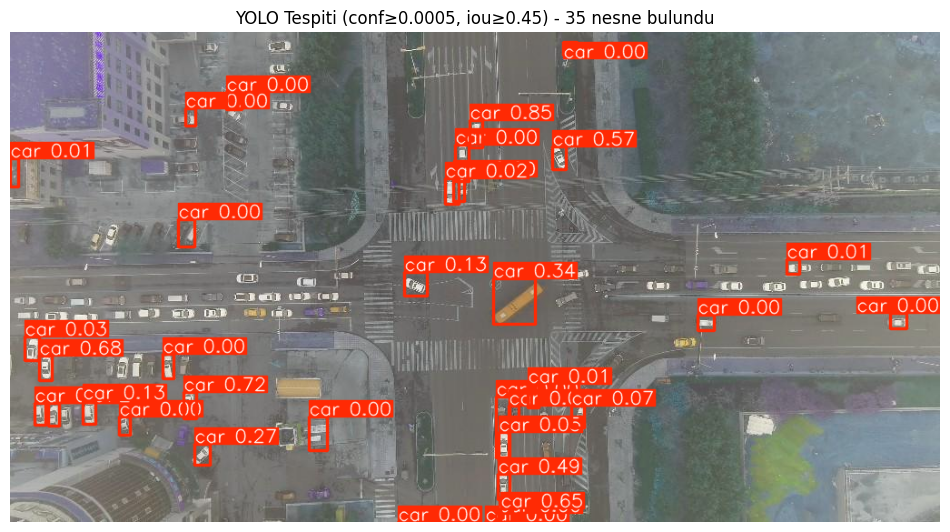


Toplam 35 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.854, Box: [507,98,521,128]
Nesne 2: Sınıf 0, Güven: 0.720, Box: [192,398,206,426]
Nesne 3: Sınıf 0, Güven: 0.678, Box: [32,358,47,384]
Nesne 4: Sınıf 0, Güven: 0.654, Box: [540,525,553,540]
Nesne 5: Sınıf 0, Güven: 0.567, Box: [597,127,612,152]
Nesne 6: Sınıf 0, Güven: 0.489, Box: [538,487,551,515]
Nesne 7: Sınıf 0, Güven: 0.343, Box: [533,273,579,323]
Nesne 8: Sınıf 0, Güven: 0.272, Box: [204,454,220,478]
Nesne 9: Sınıf 0, Güven: 0.132, Box: [435,265,460,292]
Nesne 10: Sınıf 0, Güven: 0.129, Box: [81,406,94,432]
Nesne 11: Sınıf 0, Güven: 0.067, Box: [619,413,633,436]
Nesne 12: Sınıf 0, Güven: 0.066, Box: [28,409,40,434]
Nesne 13: Sınıf 0, Güven: 0.047, Box: [538,441,550,472]
Nesne 14: Sınıf 0, Güven: 0.029, Box: [17,336,33,363]
Nesne 15: Sınıf 0, Güven: 0.025, Box: [43,410,55,435]
Nesne 16: Sınıf 0, Güven: 0.021, Box: [480,162,495,191]
Nesne 17: Sınıf 0, Güven: 0.010, Box: [0,141,10,172

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'vehicle', 2: 'truck', 3: 'bus'}
 obb: None
 orig_img: array([[[130, 124, 155],
         [130, 124, 155],
         [131, 125, 156],
         ...,
         [130, 146, 158],
         [136, 152, 164],
         [142, 158, 170]],
 
        [[133, 127, 158],
         [133, 127, 158],
         [133, 127, 158],
         ...,
         [132, 148, 160],
         [136, 152, 164],
         [139, 155, 167]],
 
        [[136, 130, 161],
         [136, 130, 161],
         [135, 129, 160],
         ...,
         [134, 150, 162],
         [135, 151, 163],
         [136, 152, 164]],
 
        ...,
 
        [[139, 136, 131],
         [137, 134, 129],
         [134, 131, 126],
         ...,
         [134, 139, 130],
         [133, 138, 129],
         [133, 138, 129]],
 
        [[139, 136, 132],
         [136, 133, 129],
         [132, 129, 125],

In [88]:
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo9_train/yolov9_new_train/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.0005)